In [103]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [104]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
words[:8]

32033


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [105]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [106]:
block_size = 3
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        #print(context)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)
        

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [107]:
C = torch.randn((27, 2))

In [108]:
emb = C[X]
#print(emb)
print(emb[:,0,:][0])
#print(torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], dim=1))
print(torch.unbind(emb, 1))

tensor([-1.9660,  0.3486])
(tensor([[-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [ 0.4891, -0.9050],
        [-0.2105, -0.8617],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [ 1.0035, -1.4977],
        [-0.2144, -0.8107],
        [ 1.7421, -0.1049],
        [-0.9614, -0.6015],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [ 1.3463, -0.1883],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [ 1.7421, -0.1049],
        [ 0.4377, -2.5372],
        [ 1.3463, -0.1883],
        [-0.0885,  1.7643],
        [ 0.4891, -0.9050],
        [-0.2144, -0.8107],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [ 0.4377, -2.5372],
        [ 1.0035, -1.4977],
        [ 0.3737, -1.0414],
        [ 0.3643, -0.7189]]), tensor([[-1.9660,  0.3486],
        [-1.9660,  0.3486],
        [ 0.4891, 

In [109]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

We need to reshape the embeddings so that their shape matches W1 because we want to multiply them using matrix multiplication.

One way to do this is by using unbind() and cat():

In [110]:
print(torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape)
# Or use unbind():
print(torch.cat(torch.unbind(emb, 1), 1).shape)

torch.Size([32, 6])
torch.Size([32, 6])


Another way is to use view():

In [111]:
emb.view(32, 6)[0]

tensor([-1.9660,  0.3486, -1.9660,  0.3486, -1.9660,  0.3486])

view() is more efficient because it usually does not move or copy the underlying data. Instead, it returns a new Tensor that shares the same underlying storage while interpreting the data with different dimensions.

In [112]:
# # A cleaner implementation

In [113]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [114]:
emb = C[X]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2

# Now you can use:

# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()

# Or
loss = F.cross_entropy(logits, Y)
loss

tensor(29.6480)

F.cross_entropy(logits, Y) is preferable because it is numerically stable, more efficient, and simpler. It combines the softmax operation and the negative log-likelihood calculation internally.

F.cross_entropy(logits, targets) computes the cross-entropy loss directly from the logits. Internally, it applies a numerically stable version of log-softmax and then computes the negative log-likelihood for the target classes.

Logits → Softmax → Correct-class probability → Negative log → Mean loss

## Mini-Batch Training and Learning Rate Selection

In [115]:
for p in parameters:
  p.requires_grad = True

In [116]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [117]:
lri = []
lossi = []

for i in range(1000):
     # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
  
    # forward pass
    emb = C[X[ix]] # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())
  
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
  
    # update
    lr = lrs[i]
    #lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

#print(loss.item())

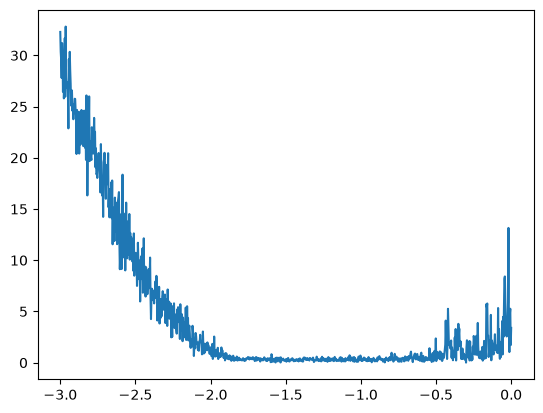

In [118]:
plt.plot(lri, lossi)

A learning rate corresponding to -1 on the log10 scale was roughly a good choice.

In [119]:
# Loss for the whole dataset

emb = C[X] # (32, 3, 10)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(4.2511, grad_fn=<NllLossBackward0>)

So we choose a good learning rate, start training with it, and decay it toward the end of training.

Train/Dev/Test

In [120]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [121]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [122]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [123]:
for p in parameters:
  p.requires_grad = True

In [124]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [125]:
lri = []
lossi = []
stepi = []

In [126]:
for i in range(200000):
    
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

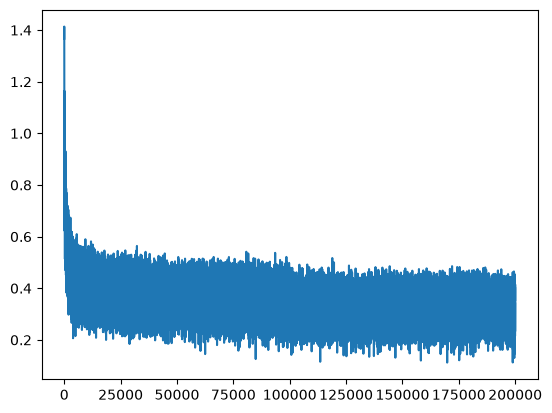

In [127]:
plt.plot(stepi, lossi)

In [128]:
# Train loss
emb = C[Xtr]  # (num_examples, 3, 10)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (num_examples, 200)
logits = h @ W2 + b2  # (num_examples, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1237, grad_fn=<NllLossBackward0>)

In [129]:
# Dev loss
emb = C[Xdev]  # (num_examples, 3, 10)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (num_examples, 200)
logits = h @ W2 + b2  # (num_examples, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1674, grad_fn=<NllLossBackward0>)

In [130]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all zeros
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amelle.
khiwmeli.
thtyn.
kandane.
mahneeferesync.
kaeli.
nerenia.
chaiir.
kaleigh.
ham.
joce.
quinn.
shon.
walianni.
waython.
jaryn.
karmen.
dusabee.
deci.
